# Designing a Dynamic Model of Service Selection and Scheduling in the Cloud Manufacturing Environment

## Three factors compose a scheduling problem:
* <font color='red'>**Features of the Problem:**</font> (workshop circumstances and the technical constraints of the processes)
Service Selection and Scheduling in the dynamic cloud  manufacturing environment, can be seen as a <font color='yellow Green'>**flexible job shop scheduling problem with:**</font>
 * sequence flexibility 
 * periods of unavailability of the services
 * transportation times between the providers

* <font color='red'>**Objective function:**</font>
 * single/multi objective
 * single/multi layar 

* <font color='red'>**solving method:**</font>
 * exact as MILP
 * half-heuristic-half-exact as constraint programming
 * heuristic as ACO

In [1]:
import json
import numpy as np
instance ='S11-T1-Transportation1-AvailabilityFloat' #'S10-T1-Transportation1-AvaiabilityFixed'#'S17-T4T5-Transportation3-AvailabilityFloating'#'S16-T4T5-Transportation3-AvailabilityFixed'# 'S15-T5-Transportation4-AvailabilityFixed'#'S14-T5-Transportation3-AvailabilityFixed'#'S13-T4-Transportation3-AvailabilityFixed'#'S12-T3-Transportation2-AvailabilityFied&Float'## #   ### # 'mops21 - Copy (5)' * mops21 - Copy (5) - Copy * mops21 - Copy (5) - Copy - Copy
with open('instances/' + instance + '.json') as data_file:
        data = json.load(data_file)
print('running ' + instance)

running S11-T1-Transportation1-AvailabilityFloat


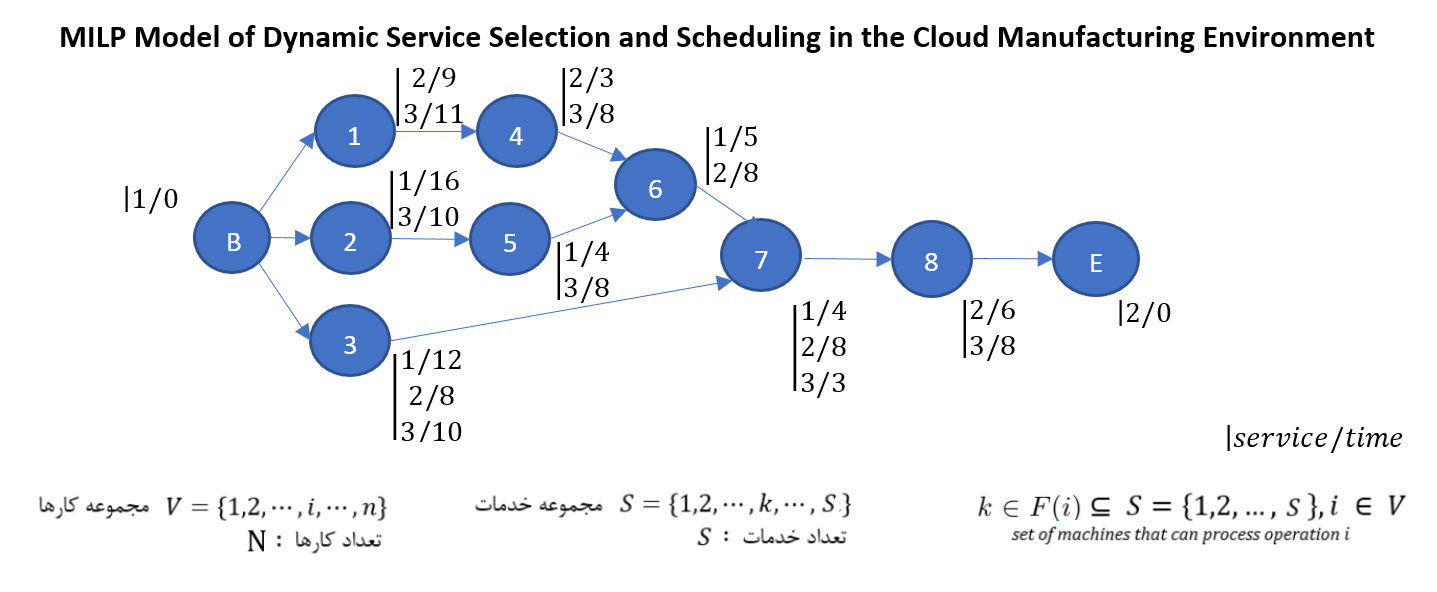

In [2]:
N = sum(len(j["topology"]) for j in data["jobs"])          #تعداد کارها
print('تعداد کارها:', N)

A = [(o["id"] - 1, p - 1) for j in data["jobs"] for o in j["topology"] for p in o["sucessors"]] # ماتریس لیست تقدم و تاخر کارها
print('لیست تقدم و تاخر کارها:',A)

S = len(data["resources"])                                # تعداد خدمات
print('تعداد خدمات:', S)

F = [[m - 1 for m in o["resources"]] for j in data["jobs"] for o in j["topology"]]
print('لیست خدمات واجد شرایط برای اجرای هر کار :',F)


B = []                                                     # لیست کارهایی که هر خدمت مجاز به اجرای آنها می باشد
for k in range(S):
    processed_by_k = []
    for i in range(N):
        if k in F[i]:
            processed_by_k.append(i)
    B.append(processed_by_k)
print('لیست کارهایی که هر خدمت مجاز به اجرای آنها می باشد' , B)

تعداد کارها: 10
لیست تقدم و تاخر کارها: [(0, 1), (0, 2), (0, 3), (1, 4), (2, 5), (3, 7), (4, 6), (5, 6), (6, 7), (7, 8), (8, 9)]
تعداد خدمات: 3
لیست خدمات واجد شرایط برای اجرای هر کار : [[0], [1, 2], [0, 2], [0, 1, 2], [1, 2], [0, 2], [0, 1], [0, 1, 2], [1, 2], [1]]
لیست کارهایی که هر خدمت مجاز به اجرای آنها می باشد [[0, 2, 3, 5, 6, 7], [1, 3, 4, 6, 7, 8, 9], [1, 2, 3, 4, 5, 7, 8]]


In [3]:
from docplex.mp.model import Model
from docplex.mp.progress import ProgressListener
from docplex.util.environment import get_environment
terminal_output = False
running_time = 7200.0
mdl = Model(name='Dynamic service selection and scheduling in cloud manufacturing = FJSP-DAG-Unavaiability-Transportation')
mdl.parameters.threads     = 1
mdl.parameters.mip.tolerances.mipgap    = float(0.0)
mdl.parameters.mip.tolerances.absmipgap = float(0.0)

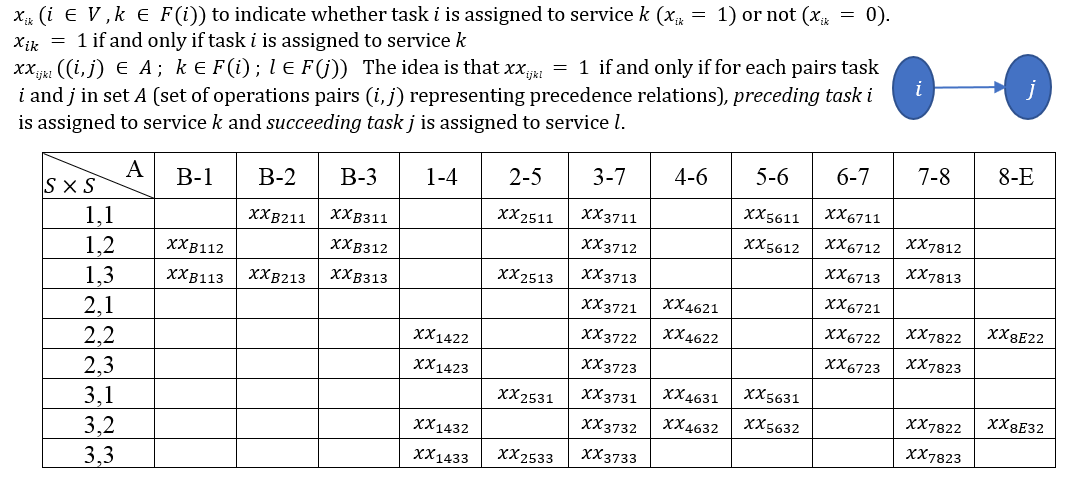

In [4]:
XX={}
for element in A:
    i = element[0]
    j = element[1]
    for k in F[i]:
        for l in F[j]:
            XX[(i,j,k,l)]= mdl.binary_var()   # mdl.binary_var()# mdl.integer_var()               # xx(i,j,g,h)
print(XX)

{(0, 1, 0, 1): docplex.mp.Var(type=B), (0, 1, 0, 2): docplex.mp.Var(type=B), (0, 2, 0, 0): docplex.mp.Var(type=B), (0, 2, 0, 2): docplex.mp.Var(type=B), (0, 3, 0, 0): docplex.mp.Var(type=B), (0, 3, 0, 1): docplex.mp.Var(type=B), (0, 3, 0, 2): docplex.mp.Var(type=B), (1, 4, 1, 1): docplex.mp.Var(type=B), (1, 4, 1, 2): docplex.mp.Var(type=B), (1, 4, 2, 1): docplex.mp.Var(type=B), (1, 4, 2, 2): docplex.mp.Var(type=B), (2, 5, 0, 0): docplex.mp.Var(type=B), (2, 5, 0, 2): docplex.mp.Var(type=B), (2, 5, 2, 0): docplex.mp.Var(type=B), (2, 5, 2, 2): docplex.mp.Var(type=B), (3, 7, 0, 0): docplex.mp.Var(type=B), (3, 7, 0, 1): docplex.mp.Var(type=B), (3, 7, 0, 2): docplex.mp.Var(type=B), (3, 7, 1, 0): docplex.mp.Var(type=B), (3, 7, 1, 1): docplex.mp.Var(type=B), (3, 7, 1, 2): docplex.mp.Var(type=B), (3, 7, 2, 0): docplex.mp.Var(type=B), (3, 7, 2, 1): docplex.mp.Var(type=B), (3, 7, 2, 2): docplex.mp.Var(type=B), (4, 6, 1, 0): docplex.mp.Var(type=B), (4, 6, 1, 1): docplex.mp.Var(type=B), (4, 6, 2, 0

In [5]:
#X       = {(i, k)    : mdl.binary_var() for i in range(n) for k in M[i]}                            # x(ik)
#print(X)

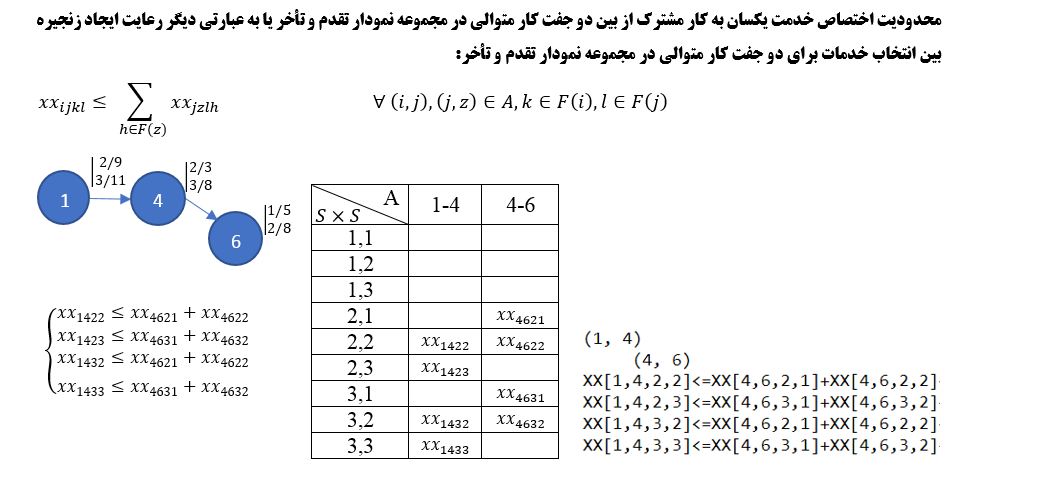

In [6]:
for el1 in A:
    i=el1[0]
    j=el1[1]
    print(el1)
    for el2 in A: 
        if j==el2[0]: #element2[0]== element[1]:
            print('    ' , el2)
            z=el2[1]
            for k in F[i]:#element[0]
                for l in F[j]:#element[1]
                    str_xx =''
                    #sum1= mdl.sum(XX[element2[0], element2[1], h, hf] for hf in M[element2[1]]) # gf for gf in M[element2[0]]
                    sum1= mdl.sum(XX[j, z, l, f] for f in F[z]) # gf for gf in M[element2[0]]
                    for f in F[el2[1]]:
                        str_xx +='XX[' + str(j)+',' +str(z) + ',' + str(l+1) + ',' + str(f+1) + ']+'
                    print('XX[' + str(i)+','+str(j)+','+str(k+1)+','+str(l+1)+']<=' + str_xx)
                    #mdl.add_constraint(XX[element[0],element[1],g,h] <= sum1 ) 
                    mdl.add_constraint(XX[i,j,k,l] <= sum1 )

(0, 1)
     (1, 4)
XX[0,1,1,2]<=XX[1,4,2,2]+XX[1,4,2,3]+
XX[0,1,1,3]<=XX[1,4,3,2]+XX[1,4,3,3]+
(0, 2)
     (2, 5)
XX[0,2,1,1]<=XX[2,5,1,1]+XX[2,5,1,3]+
XX[0,2,1,3]<=XX[2,5,3,1]+XX[2,5,3,3]+
(0, 3)
     (3, 7)
XX[0,3,1,1]<=XX[3,7,1,1]+XX[3,7,1,2]+XX[3,7,1,3]+
XX[0,3,1,2]<=XX[3,7,2,1]+XX[3,7,2,2]+XX[3,7,2,3]+
XX[0,3,1,3]<=XX[3,7,3,1]+XX[3,7,3,2]+XX[3,7,3,3]+
(1, 4)
     (4, 6)
XX[1,4,2,2]<=XX[4,6,2,1]+XX[4,6,2,2]+
XX[1,4,2,3]<=XX[4,6,3,1]+XX[4,6,3,2]+
XX[1,4,3,2]<=XX[4,6,2,1]+XX[4,6,2,2]+
XX[1,4,3,3]<=XX[4,6,3,1]+XX[4,6,3,2]+
(2, 5)
     (5, 6)
XX[2,5,1,1]<=XX[5,6,1,1]+XX[5,6,1,2]+
XX[2,5,1,3]<=XX[5,6,3,1]+XX[5,6,3,2]+
XX[2,5,3,1]<=XX[5,6,1,1]+XX[5,6,1,2]+
XX[2,5,3,3]<=XX[5,6,3,1]+XX[5,6,3,2]+
(3, 7)
     (7, 8)
XX[3,7,1,1]<=XX[7,8,1,2]+XX[7,8,1,3]+
XX[3,7,1,2]<=XX[7,8,2,2]+XX[7,8,2,3]+
XX[3,7,1,3]<=XX[7,8,3,2]+XX[7,8,3,3]+
XX[3,7,2,1]<=XX[7,8,1,2]+XX[7,8,1,3]+
XX[3,7,2,2]<=XX[7,8,2,2]+XX[7,8,2,3]+
XX[3,7,2,3]<=XX[7,8,3,2]+XX[7,8,3,3]+
XX[3,7,3,1]<=XX[7,8,1,2]+XX[7,8,1,3]+
XX[3,7,3,2]<=X

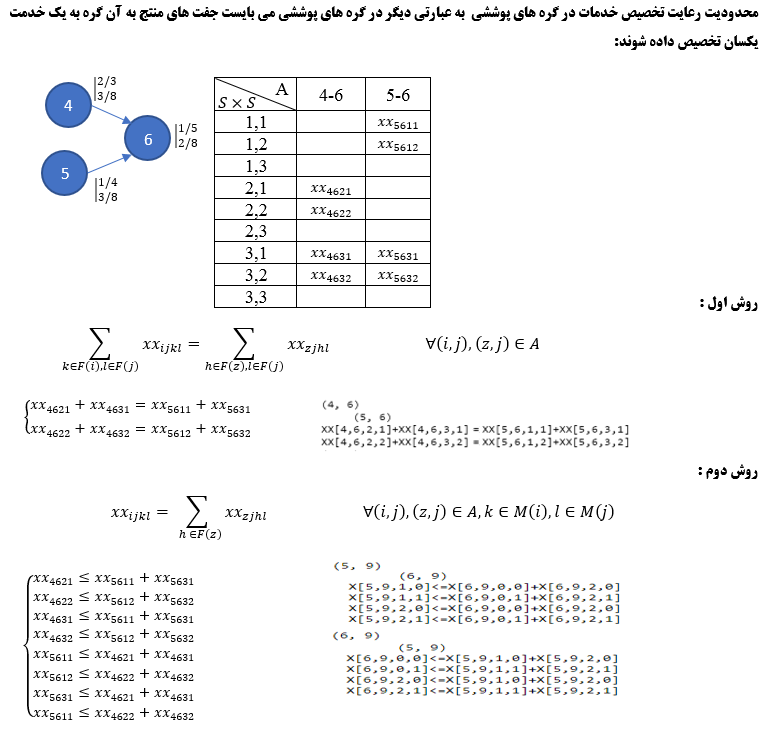

In [7]:
                                                                   # روش دوم
for el1 in A:
    print(el1)
    i=el1[0]
    j=el1[1]
    for el2 in A :
        print('     ' ,el2)
        if j==el2[1] and i != el2[0] :
            z=el2[0]
            for k in F[i]:
                for l in F[j]:
                    sum1=mdl.sum(XX[z,j,h,l] for h in F[z])
                    str_sum1=''
                    for h in F[z]:
                        str_sum1 += 'XX[' + str(z) +  ',' + str(j) + ',' + str(h) + ','+  str(l) + ']+'
                    print('XX[' + str(i) +  ',' + str(j) + ',' + str(k) + ','+  str(l) + ']<=' + str_sum1)
                    mdl.add_constraint(XX[i,j,k,l] <= sum1)

(0, 1)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(0, 2)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(0, 3)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(1, 4)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(2, 5)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(3, 7)
      (0, 1)
      (0, 2)
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
XX[3,7,0,0]<=XX[6,7,0,0]+XX[6,7,1,0]+
XX[3,7,0,1]<=XX[6,7,0,1]+XX[6,7,1,1]+
XX[3,7,0,2]<=XX[6,7,0,2]+XX[6,7,1,2]+
XX[3,7,1,0]<

In [8]:
                                                                     # روش اول
#for element in A: 
#    print(element)
#    for element2 in A: 
#        if element2[1]== element[1] and element2[0] != element[0] and element2[0] > element[0] :
#            print('    ' , element2)
#            for h in M[element[1]]:
#                sum1= mdl.sum(XX[element[0], element[1], gf , h] for gf in M[element[0]])
#                str_sum1=''
#                for gf in M[element[0]]:
#                    str_sum1 += 'XX[' + str(element[0]) +  ',' + str(element[1]) + ',' + str(gf+1) + ','+  str(h+1) + ']+'
#                    #print('XX[',str(element[0]), ',' , str(element[1]), ',' , str(gf), ',', str(h), ']' )
#                     #print()
#                
#                sum2= mdl.sum(XX[element2[0], element2[1], gf , h] for gf in M[element2[0]])   
#                str_sum2=''
#                for gf in M[element2[0]]:
#                    str_sum2+= 'XX[' + str(element2[0]) + ',' + str(element2[1]) + ',' + str(gf+1) + ',' + str(h+1) + ']+'
#                    #print('XX[',str(element2[0]), ',' , str(element2[1]), ',' , str(gf), ',', str(h), ']' )
#                #print()
#                print(str_sum1 +'=' + str_sum2)
#                mdl.add_constraint(sum1 == sum2 ) 

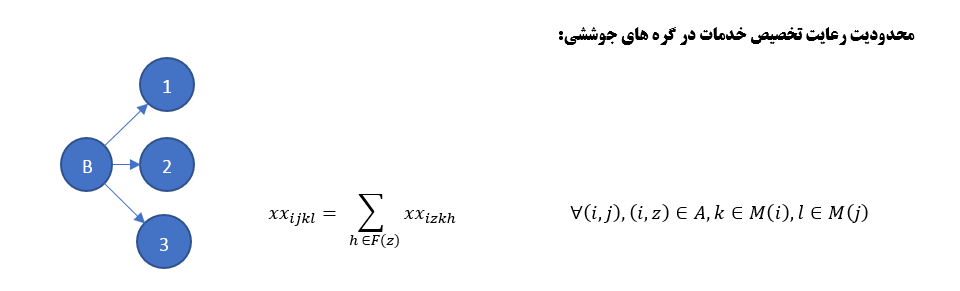

In [9]:
                                                                 # روش دوم
for el1 in A:
    print(el1)
    i=el1[0]
    j=el1[1]
    for el2 in A :
        print('     ' ,el2)
        if i==el2[0] and j != el2[1] :
            z=el2[1]
            for k in F[i]:
                for l in F[j]:
                    sum1=mdl.sum(XX[i,z,k,h] for h in F[z])
                    str_sum1=''
                    for h in F[z]:
                        str_sum1 += 'XX[' + str(i) +  ',' + str(z) + ',' + str(k) + ','+  str(h) + ']+'
                    print('XX[' + str(i) +  ',' + str(j) + ',' + str(k) + ','+  str(l) + ']<=' + str_sum1)
                    mdl.add_constraint(XX[i,j,k,l] <= sum1)

(0, 1)
      (0, 1)
      (0, 2)
XX[0,1,0,1]<=XX[0,2,0,0]+XX[0,2,0,2]+
XX[0,1,0,2]<=XX[0,2,0,0]+XX[0,2,0,2]+
      (0, 3)
XX[0,1,0,1]<=XX[0,3,0,0]+XX[0,3,0,1]+XX[0,3,0,2]+
XX[0,1,0,2]<=XX[0,3,0,0]+XX[0,3,0,1]+XX[0,3,0,2]+
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(0, 2)
      (0, 1)
XX[0,2,0,0]<=XX[0,1,0,1]+XX[0,1,0,2]+
XX[0,2,0,2]<=XX[0,1,0,1]+XX[0,1,0,2]+
      (0, 2)
      (0, 3)
XX[0,2,0,0]<=XX[0,3,0,0]+XX[0,3,0,1]+XX[0,3,0,2]+
XX[0,2,0,2]<=XX[0,3,0,0]+XX[0,3,0,1]+XX[0,3,0,2]+
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6, 7)
      (7, 8)
      (8, 9)
(0, 3)
      (0, 1)
XX[0,3,0,0]<=XX[0,1,0,1]+XX[0,1,0,2]+
XX[0,3,0,1]<=XX[0,1,0,1]+XX[0,1,0,2]+
XX[0,3,0,2]<=XX[0,1,0,1]+XX[0,1,0,2]+
      (0, 2)
XX[0,3,0,0]<=XX[0,2,0,0]+XX[0,2,0,2]+
XX[0,3,0,1]<=XX[0,2,0,0]+XX[0,2,0,2]+
XX[0,3,0,2]<=XX[0,2,0,0]+XX[0,2,0,2]+
      (0, 3)
      (1, 4)
      (2, 5)
      (3, 7)
      (4, 6)
      (5, 6)
      (6,

In [10]:
                                                             # روش اول
#for element in A: 
#    print(element)
#    for element2 in A: 
#        if element2[0]== element[0] and element2[1] != element[1] and element2[1] > element[1] :
#            print('    ' , element2)
#            for h in M[element[0]]:
#                sum1= mdl.sum(XX[element[0], element[1], h,  gf] for gf in M[element[1]])
#                str_sum1=''
#                for gf in M[element[1]]:
#                    str_sum1 += 'XX[' + str(element[0]) +  ',' + str(element[1]) + ',' + str(h+1) + ','+  str(gf+1) + ']+'
#                    #print('XX[',str(element[0]), ',' , str(element[1]), ',' , str(gf), ',', str(h), ']' )
#                #print()
#                
#                sum2= mdl.sum(XX[element2[0], element2[1], h , gf] for gf in M[element2[1]])   
#                str_sum2=''
#                for gf in M[element2[1]]:
#                    str_sum2+= 'XX[' + str(element2[0]) + ',' + str(element2[1]) + ',' + str(h+1) + ',' + str(gf+1) + ']+'
#                    #print('XX[',str(element2[0]), ',' , str(element2[1]), ',' , str(gf), ',', str(h), ']' )
#                #print()
#                print(str_sum1 +'=' + str_sum2)
#                mdl.add_constraint(sum1 == sum2 ) 

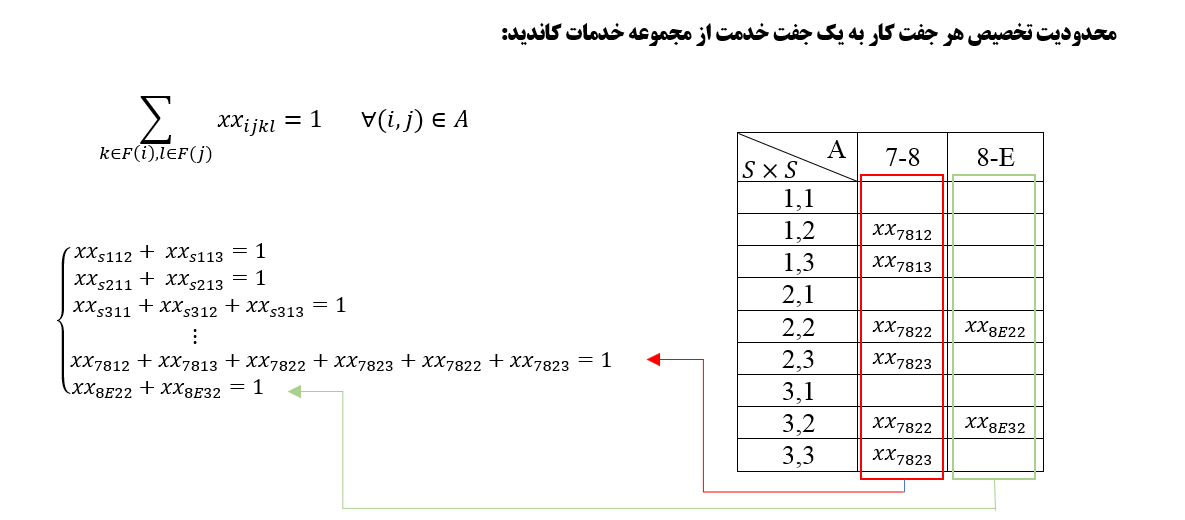

In [11]:
for element in A:
    i = element[0]
    j = element[1]
    mdl_sum = mdl.sum(XX[i,j,k,l] for k in F[i] for l in F[j])
    mdl.add_constraint(mdl_sum == 1)

In [12]:
#for i in range(n):
#    mdl_sum =mdl.sum(X[i, k] for k in M[i])
#    mdl.add_constraint(mdl_sum == 1) 

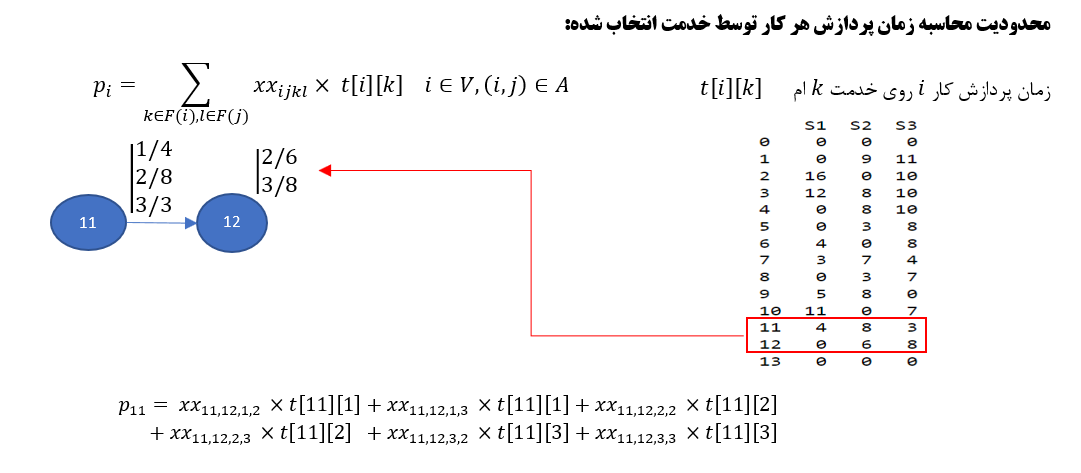

In [13]:
tt = []                                                       # محاسبه زمان برای ماشین های مجاز و غیر مجاز
for j in data["jobs"]:
    # ttt = []
    for o in j["topology"]:
        ttttt = o["time"]
        #print(ttttt)
        tttt = []
        io = 0
        for f in range(S):
            if f+1 in o["resources"]:                
                tttt.append (ttttt[io])
                io += 1
            else:
                tttt.append (0)
        tt.append(tttt) #ttt.append(tttt)
    #tt.append(ttt)
print(tt)
#aa = np.array(tt)
#print(aa)
#print(aa.shape)
#bb = aa.reshape(N,20)
#print(bb)
#print(tt[0][1][2])
#print(tt[1][22][2])

        
    
import pandas as pd
if instance =='S10-T1-Transportation1-AvaiabilityFixed'or instance =='S11-T1-Transportation1-AvailabilityFloat':
    df= pd.DataFrame(tt,columns = ['S1','S2','S3']) #tt[0]
elif instance =='S12-T3-Transportation2-AvailabilityFied&Float':
    df= pd.DataFrame(tt,columns = ['S1','S2','S3','S4','S5'])#tt[0] 
elif instance =='S13-T4-Transportation3-AvailabilityFixed' or instance =='S14-T5-Transportation3-AvailabilityFixed': 
    df= pd.DataFrame(tt,columns = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10'])#tt[0]
elif instance =='S15-T5-Transportation4-AvailabilityFixed'or instance =='S16-T4T5-Transportation3-AvailabilityFixed'or instance =='S17-T4T5-Transportation3-AvailabilityFloating': 
    df= pd.DataFrame(tt,columns = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12','S13','S14','S15','S16','S17','S18','S19','S20'])# tt[0]
print(df)                                                                 


t = [o["time"] for j in data["jobs"] for o in j["topology"]] #  زمان اجرای هر کار روی خدمت مربوطه
print('زمان اجرای هر کار روی خدمت مجاز مربوطه:', t)

LOC = [o["resources"] for j in data["jobs"] for o in j["topology"]] #  زمان اجرای هر کار روی خدمت مربوطه
print('ماشین های مجار برای هر کار:', LOC)
print(LOC[-1:][0][0])
p       = {i : mdl.continuous_var() for i in range(N)} # زمان اجرای عملیات بر روی ماشین انتخاب شده 
print(p)

for i in range(N):
    for el in A:
        if i == el[0]:
            #print(el[0] , ',' , el[1])
            j = el[1]
            #if i == 38:
            #    print(F[i])
            #    print(j)
            #    print(F[j])
            #    for  k in F[i]:
            #        for l in F[j]:
            #            print('XX[' + str(i) + ',' + str(j) +',' + str(k) + ',' +str(l) + ']')
            #            print(tt[i][k])
            #proc_sum = mdl.sum(X[i,j, F[i][k], F[j][l]] * t[i][k] for k in range(len(F[i])) for l in range(len(F[j])))                               
            proc_sum = mdl.sum(XX[i,j, k, l] * tt[i][k] for k in F[i] for l in F[j]) # tt[0][i][k]
            mdl.add_constraint(p[i] == proc_sum) 
            break

[[0, 0, 0], [0, 9, 11], [16, 0, 10], [12, 8, 10], [0, 3, 8], [4, 0, 8], [5, 8, 0], [4, 8, 3], [0, 6, 8], [0, 0, 0]]
   S1  S2  S3
0   0   0   0
1   0   9  11
2  16   0  10
3  12   8  10
4   0   3   8
5   4   0   8
6   5   8   0
7   4   8   3
8   0   6   8
9   0   0   0
زمان اجرای هر کار روی خدمت مجاز مربوطه: [[0], [9, 11], [16, 10], [12, 8, 10], [3, 8], [4, 8], [5, 8], [4, 8, 3], [6, 8], [0]]
ماشین های مجار برای هر کار: [[1], [2, 3], [1, 3], [1, 2, 3], [2, 3], [1, 3], [1, 2], [1, 2, 3], [2, 3], [2]]
2
{0: docplex.mp.Var(type=C), 1: docplex.mp.Var(type=C), 2: docplex.mp.Var(type=C), 3: docplex.mp.Var(type=C), 4: docplex.mp.Var(type=C), 5: docplex.mp.Var(type=C), 6: docplex.mp.Var(type=C), 7: docplex.mp.Var(type=C), 8: docplex.mp.Var(type=C), 9: docplex.mp.Var(type=C)}


In [14]:
#p       = {i : mdl.continuous_var() for i in range(n)} # زمان اجرای عملیات بر روی ماشین انتخاب شده 
#print(p)
#for i in range(n):
#    proc_sum = mdl.sum(X[i, M[i][k]] * t[i][k] for k in range(len(M[i])))                                  
#    mdl.add_constraint(p[i] == proc_sum)               

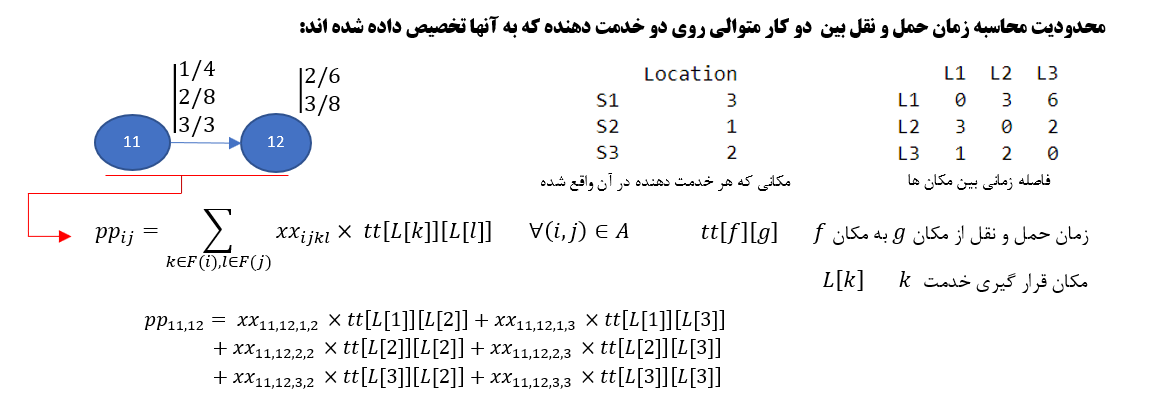

In [15]:
TRT = [i["loc_time"]  for i in data["city"] ]
print('فاصله زمانی بین شهرها:' , TRT)
if instance =='S10-T1-Transportation1-AvaiabilityFixed'or instance =='S11-T1-Transportation1-AvailabilityFloat':
    df1= pd.DataFrame(TRT,index = ['L1','L2','L3'] , columns= ['L1','L2','L3'])  
elif instance =='S12-T3-Transportation2-AvailabilityFied&Float':
    df1= pd.DataFrame(TRT,index = ['L1','L2','L3','L4','L5'] , columns= ['L1','L2','L3','L4','L5']) 
elif instance =='S13-T4-Transportation3-AvailabilityFixed' or instance =='S14-T5-Transportation3-AvailabilityFixed':  
    df1= pd.DataFrame(TRT,index = ['L1','L2','L3','L4','L5','L6','L7','L8','L9'] , columns= ['L1','L2','L3','L4','L5','L6','L7','L8','L9'])
elif instance =='S15-T5-Transportation4-AvailabilityFixed'or instance =='S16-T4T5-Transportation3-AvailabilityFixed' or instance =='S17-T4T5-Transportation3-AvailabilityFloating': 
    df1= pd.DataFrame(TRT,index = ['L1','L2','L3','L4','L5','L6','L7','L8','L9','L10','L11','L12','L13','L14','L15','L16','L17','L18','L19','L20'] , columns= ['L1','L2','L3','L4','L5','L6','L7','L8','L9','L10','L11','L12','L13','L14','L15','L16','L17','L18','L19','L20'])
print(df1)                                                                 



TRL = [i["loc"] for i in data["resources"]]
#print('مکان یا شهری که هر خدمت در آن واقع می باشد:' , TRL)
if instance =='S10-T1-Transportation1-AvaiabilityFixed'or instance =='S11-T1-Transportation1-AvailabilityFloat':
    df2= pd.DataFrame(TRL,index = ['S1','S2','S3'],columns= ['Location'])   
elif instance =='S12-T3-Transportation2-AvailabilityFied&Float':
    df2= pd.DataFrame(TRL,index = ['S1','S2','S3','S4','S5'],columns= ['Location'])
elif instance =='S13-T4-Transportation3-AvailabilityFixed' or instance =='S14-T5-Transportation3-AvailabilityFixed': 
    df2= pd.DataFrame(TRL,index = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10'],columns= ['Location'])
elif instance =='S15-T5-Transportation4-AvailabilityFixed'or instance =='S16-T4T5-Transportation3-AvailabilityFixed' or instance =='S17-T4T5-Transportation3-AvailabilityFloating': 
     df2= pd.DataFrame(TRL,index = ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12','S13','S14','S15','S16','S17','S18','S19','S20'],columns= ['Location'])
print(df2)
print()
print(df2[-1:])
print(df2['Location'].iloc[-1])
pp={}                             #  متغیر زمان حمل و نقل بین دو عملیات بر اساس اینکه به کدام دو خدمت اختصاص داده می شوند
for el in A:
    i = el[0]
    j = el[1]
    pp[(i,j)]= mdl.continuous_var()
print(pp) 

for el in A:
    i = el[0]
    j = el[1]   
    proc_sum = mdl.sum( XX[i,j,k,l] * TRT[TRL[k][0]-1][TRL[l][0]-1] for k in F[i] for l in F[j])
    mdl.add_constraint(pp[i,j] == proc_sum) 

فاصله زمانی بین شهرها: [[0, 3, 1], [3, 0, 2], [1, 2, 0]]
    L1  L2  L3
L1   0   3   1
L2   3   0   2
L3   1   2   0
    Location
S1         3
S2         1
S3         2

    Location
S3         2
2
{(0, 1): docplex.mp.Var(type=C), (0, 2): docplex.mp.Var(type=C), (0, 3): docplex.mp.Var(type=C), (1, 4): docplex.mp.Var(type=C), (2, 5): docplex.mp.Var(type=C), (3, 7): docplex.mp.Var(type=C), (4, 6): docplex.mp.Var(type=C), (5, 6): docplex.mp.Var(type=C), (6, 7): docplex.mp.Var(type=C), (7, 8): docplex.mp.Var(type=C), (8, 9): docplex.mp.Var(type=C)}


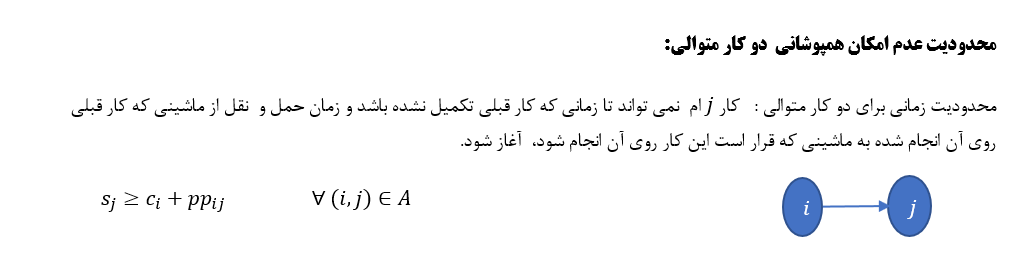

In [16]:
s   = {i : mdl.continuous_var() for i in range(N)} # s(i) 
c   = {i : mdl.continuous_var() for i in range(N)} # c(i)
for el in A:
    i = el[0]
    j = el[1] 
    mdl.add_constraint(c[i]+pp[i,j]<=s[j]) # s[i]+p[i]

In [17]:
#for element in A:                                 
#    i = element[0]
#    j = element[1]
#    mdl.add_constraint(s[i] + p[i] <= s[j] + p[j])
#    mdl.add_constraint(c[i] <= c[j])

In [18]:
for i in range(N):
    mdl.add_constraint(c[i] == s[i] + p[i])

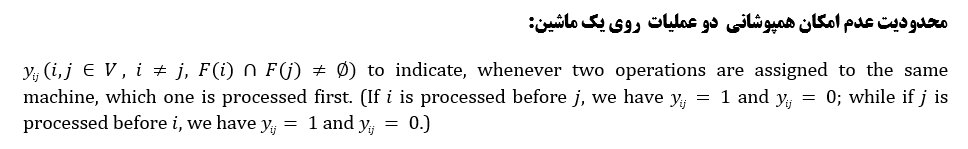

In [19]:
#Y={}
#for i in range(N):
#    for j in range(N):
#        if i != j:
            #has_one = False # True if exist machine k which proc. i and j
            #for machine in M[i]:
            #    if machine in M[j]:
            #        has_one = True
            #if has_one:
#            for k in range(S):
#                if k in F[i] and k in F[j]:
#                    Y[(i, j)]= mdl.binary_var()
                   
#Y = {}

#for i in range(N):
#    for j in range(N):
#       if i != j and set(F[i]).intersection(F[j]):
#            Y[i, j] = mdl.binary_var()     
#print(Y) 


# ============================================================
# CELL 29
# Sequencing variables (Y) and assignment expressions
# ============================================================
# ------------------------------------------------------------
# Identify incoming and outgoing arcs for every subtask
# ------------------------------------------------------------
out_arcs = {i: [] for i in range(N)}
in_arcs  = {i: [] for i in range(N)}
for i, j in A:
    out_arcs[i].append(j)
    in_arcs[j].append(i)

# ------------------------------------------------------------
# Terminal nodes
# A terminal node has no outgoing precedence arc.
# In the current JSON data, these are the virtual end nodes
# already defined in each DAG.
# ------------------------------------------------------------
terminal_nodes = [
    i for i in range(N)
    if len(out_arcs[i]) == 0
]
print("Terminal nodes (0-based):", terminal_nodes)
print("Terminal nodes (original IDs):",
      [i + 1 for i in terminal_nodes])

# ------------------------------------------------------------
# Helper:
# expression indicating whether subtask i is assigned to
# service k.
#
# For a normal/source node:
#     use one outgoing DAG edge.
#
# For a terminal node:
#     use one incoming DAG edge.
#
# This is possible because the structural XX constraints
# enforce consistent service selection for each subtask.
# ------------------------------------------------------------
def service_assignment_expr(i, k):
    # Case 1: node has an outgoing arc
    if len(out_arcs[i]) > 0:
        j = out_arcs[i][0]
        if k not in F[i]:
            return 0
        return mdl.sum(
            XX[i, j, k, l]
            for l in F[j]
        )
    # Case 2: terminal node
    elif len(in_arcs[i]) > 0:
        h = in_arcs[i][0]
        if k not in F[i]:
            return 0
        return mdl.sum(
            XX[h, i, l, k]
            for l in F[h]
        )
    # Isolated node (should not occur in a valid DAG)
    return 0

# ------------------------------------------------------------
# Create Y variables only for pairs of subtasks that have at
# least one common eligible manufacturing service.
# ------------------------------------------------------------
Y = {}
for i in range(N):
    for j in range(i + 1, N):
        common_services = set(F[i]).intersection(F[j])
        if common_services:
            Y[i, j] = mdl.binary_var(
                name=f"Y_{i}_{j}"
            )
            Y[j, i] = mdl.binary_var(
                name=f"Y_{j}_{i}"
            )
print("Number of Y variables:", len(Y))
print(Y) 

Terminal nodes (0-based): [9]
Terminal nodes (original IDs): [10]
Number of Y variables: 78
{(0, 2): docplex.mp.Var(type=B,name='Y_0_2'), (2, 0): docplex.mp.Var(type=B,name='Y_2_0'), (0, 3): docplex.mp.Var(type=B,name='Y_0_3'), (3, 0): docplex.mp.Var(type=B,name='Y_3_0'), (0, 5): docplex.mp.Var(type=B,name='Y_0_5'), (5, 0): docplex.mp.Var(type=B,name='Y_5_0'), (0, 6): docplex.mp.Var(type=B,name='Y_0_6'), (6, 0): docplex.mp.Var(type=B,name='Y_6_0'), (0, 7): docplex.mp.Var(type=B,name='Y_0_7'), (7, 0): docplex.mp.Var(type=B,name='Y_7_0'), (1, 2): docplex.mp.Var(type=B,name='Y_1_2'), (2, 1): docplex.mp.Var(type=B,name='Y_2_1'), (1, 3): docplex.mp.Var(type=B,name='Y_1_3'), (3, 1): docplex.mp.Var(type=B,name='Y_3_1'), (1, 4): docplex.mp.Var(type=B,name='Y_1_4'), (4, 1): docplex.mp.Var(type=B,name='Y_4_1'), (1, 5): docplex.mp.Var(type=B,name='Y_1_5'), (5, 1): docplex.mp.Var(type=B,name='Y_5_1'), (1, 6): docplex.mp.Var(type=B,name='Y_1_6'), (6, 1): docplex.mp.Var(type=B,name='Y_6_1'), (1, 7):

In [20]:
#U = [k["availability"] for k in data["resources"]]
#avs = [[[U[k][2 * v], U[k][2 * v + 1]] for v in range(len(U[k]) // 2)] for k in range(S)]
#unavs = []
#id_unav = 0
#for k in range(S):
#    unavs_in_k = []
#    if U[k][0] > 0:
#        unavs_in_k.append((0, U[k][0], k))
#        id_unav += 1
#    for v in range(2, len(U[k]), 2):
#        unavs_in_k.append((U[k][v - 1], U[k][v], k))
#        id_unav += 1
#    unavs.append(unavs_in_k)  
#print(unavs)
#linear_unavs = [unav for unav_in_k in unavs for unav in unav_in_k]  
#print(linear_unavs)

#rightSum = 0
#for i in range(N):
#    max_value = 0
#    for k in range(len(F[i])):
#        max_value = max(max_value, t[i][k]) # + get_full_setup(M[i][g])
#    rightSum += max_value # + get_full_setup(k)
#print(rightSum)

#latestUnav = 0
#for k in range(S):
#    for unav in unavs[k]:
#        latestUnav = max(latestUnav, unav[1])
#print(latestUnav)
        
#M=latestUnav+rightSum
#print(M)
# ============================================================
# CELL 30
# Big-M calculation and machine sequencing constraints
# ============================================================


# ------------------------------------------------------------
# 1. Service unavailability data
# ------------------------------------------------------------
U = [
    resource["availability"]
    for resource in data["resources"]
]
avs = [
    [
        [U[k][2 * v], U[k][2 * v + 1]]
        for v in range(len(U[k]) // 2)
    ]
    for k in range(S)
]

# ------------------------------------------------------------
# Construct unavailability intervals
#
# Each tuple:
#     (earliest_end, latest_end, service)
#
# For an initial unavailability interval:
#     [0, U[k][0]]
#
# For subsequent intervals:
#     [U[k][v-1], U[k][v]]
# ------------------------------------------------------------

unavs = []
id_unav = 0
for k in range(S):
    unavs_in_k = []
    if U[k][0] > 0:
        unavs_in_k.append(
            (0, U[k][0], k)
        )
        id_unav += 1
    for v in range(2, len(U[k]), 2):
        unavs_in_k.append(
            (U[k][v - 1], U[k][v], k)
        )
        id_unav += 1
    unavs.append(unavs_in_k)
linear_unavs = [
    unav
    for unav_in_k in unavs
    for unav in unav_in_k
]
print("Number of unavailability intervals:",
      len(linear_unavs))

# ============================================================
# 2. Big-M calculation
# ============================================================

# ------------------------------------------------------------
# Maximum possible processing time of each subtask
#
# IMPORTANT:
# F[i] contains the actual service IDs (0-based).
# Therefore tt[i][k] must be used instead of t[i][k].
#
# tt has one entry for every service:
#     tt[i][k] = processing time of subtask i on service k
# ------------------------------------------------------------

max_proc = []
for i in range(N):
    if F[i]:
        max_proc_i = max(
            tt[i][k]
            for k in F[i]
        )
    else:
        max_proc_i = 0
    max_proc.append(max_proc_i)
H_proc = sum(max_proc)


# ------------------------------------------------------------
# Maximum transportation-time bound
# ------------------------------------------------------------

max_transport = []
for i, j in A:
    transport_values = [
        TRT[TRL[k][0] - 1][TRL[l][0] - 1]
        for k in F[i]
        for l in F[j]
    ]
    if transport_values:
        max_transport_ij = max(
            transport_values
        )
    else:
        max_transport_ij = 0
    max_transport.append(max_transport_ij)
H_transport = sum(max_transport)

# ------------------------------------------------------------
# Latest endpoint of all service-unavailability intervals
# ------------------------------------------------------------

latestUnav = 0
for k in range(S):
    for unav in unavs[k]:
        latestUnav = max(
            latestUnav,
            unav[1]
        )
H_unavailability = latestUnav

# ------------------------------------------------------------
# Conservative scheduling horizon / Big-M
# ------------------------------------------------------------

H = (
    H_unavailability
    + H_proc
    + H_transport
)
M = max(1, H)

print("--------------------------------------------")
print("BIG-M CALCULATION")
print("--------------------------------------------")
print("Maximum processing-time bound  =", H_proc)
print("Maximum transportation bound  =", H_transport)
print("Latest unavailability endpoint =", H_unavailability)
print("Scheduling horizon H           =", H)
print("Big-M                          =", M)
print("--------------------------------------------")

# ============================================================
# 3. Sequencing constraints
# ============================================================

# ------------------------------------------------------------
# If two subtasks are assigned to the same service,
# one must precede the other.
#
# For every pair (i,j) and every common service k:
#
# Y_ij + Y_ji >= X_ik + X_jk - 1
#
# ------------------------------------------------------------

for i in range(N):
    for j in range(i + 1, N):
        common_services = (
            set(F[i]).intersection(F[j])
        )
        if not common_services:
            continue
        for k in common_services:
            assign_i_k = service_assignment_expr(i, k)
            assign_j_k = service_assignment_expr(j, k)
            mdl.add_constraint(
                Y[i, j] + Y[j, i]
                >=
                assign_i_k + assign_j_k - 1
            )
# ------------------------------------------------------------
# Timing/order constraints
#
# If Y[i,j] = 1:
#
#       C_i <= S_j
#
# If Y[i,j] = 0:
#
#       C_i - M <= S_j
#
# ------------------------------------------------------------

for (i, j) in Y:
    mdl.add_constraint(
        s[i] + p[i]
        - M * (1 - Y[i, j])
        <= s[j]
    )
# EQ: 6
#for i in range(N):
#    for j in range(N):
#        if i != j:
#            has_one = False # True if exist machine k which proc. i and j
#            for machine in F[i]:
#                if machine in F[j]:
#                    has_one = True
#            if has_one:
#                for k in range(S):
#                    if k in F[i] and k in F[j]:
#                        for el in A:
#                            if el[0]==i:
#                                sumi=mdl.sum(XX[i,el[1],k,l] for l in F[el[1]])
#                                break
#                        for el in A:
#                            if el[0]==j:
#                                sumj=mdl.sum(XX[j,el[1],k,l] for l in F[el[1]])
#                                break
#                        mdl.add_constraint(Y[i,j]+Y[j,i]>= sumi+sumj -1)   

# EQ: 6
#for i in range(N):
#    for j in range(N):
#        if i != j:
#            common_mcs = set(F[i]).intersection(F[j])
#            if common_mcs:
#                for k in common_mcs:
#                    # Service-assignment indicator for subtask i on MCS k
#                    sumi = 0
#                    for el in A:
#                        if el[0] == i:
#                            sumi = mdl.sum(
#                                XX[i, el[1], k, l]
#                                for l in F[el[1]]
#                            )
#                            break
#                    # Service-assignment indicator for subtask j on MCS k
#                    sumj = 0
#                    for el in A:
#                        if el[0] == j:
#                            sumj = mdl.sum(
#                                XX[j, el[1], k, l]
#                                for l in F[el[1]]
#                           )
#                            break
#                    # If i and j are assigned to the same MCS k,
#                    # one of the two sequencing directions must be active.
#                    mdl.add_constraint(
#                        Y[i, j] + Y[j, i] >= sumi + sumj - 1
#                    )
                    
#for i in range(N):
#    for j in range(N):
#        if i != j:
#            has_one = False # True if exist machine k which proc. i and j
#            for machine in F[i]:
#                if machine in F[j]:
#                    has_one = True
#            if has_one: 
#                for k in range(S):
#                    if k in F[i] and k in F[j]:
#                        mdl.add_constraint(s[i]+p[i]-((1-Y[i,j]) * M ) <=s[j]) 

# EQ: 7
#for i in range(N):
#    for j in range(N):
#        if i != j:
#            common_mcs = set(F[i]).intersection(F[j])
#            if common_mcs:
#                for k in common_mcs:
#                    # If i and j are assigned to the same MCS k
#                    # and Y[i,j] = 1, i must finish before j starts.
#                    mdl.add_constraint(
#                        s[i] + p[i]
#                        - (1 - Y[i, j]) * M
#                        <= s[j]
#                    )

Number of unavailability intervals: 5
--------------------------------------------
BIG-M CALCULATION
--------------------------------------------
Maximum processing-time bound  = 79
Maximum transportation bound  = 29
Latest unavailability endpoint = 19
Scheduling horizon H           = 127
Big-M                          = 127
--------------------------------------------


In [21]:
#FM      = {(i,l) : mdl.continuous_var() for i in range(S) for l in range(len(unavs[i]))}
#Z       = {(i, k, l) : mdl.binary_var() for i in range(N) for k in F[i] for l in range(len(unavs[k]))}

#print(FM)

#for i in range(S):
#    for l in range(len(unavs[i])):
#        print(FM[i,l])
#print('')
#for i in range(N):
#    for k in F[i]:
#        for l in range(len(unavs[k])):
#            print(Z[i, k, l])

#PM= [k["P"] for k in data["resources"]]
#print(' مدت توقف کار پیشگیرانه اول و دوم روی هر یک از سه ماشین :',PM)
#                                        ********************   زمان مجاز شروع کار پیشگیرانه اول و دوم روی هر یک از سه ماشین
#EM= [k["EM"] for k in data["resources"]]
#print('زمان مجاز شروع کار پیشگیرانه اول و دوم روی هر یک از سه ماشین :',EM)
#                                        ********************   زمان مجاز اتمام کار پیشگیرانه اول و دوم روی هر یک از سه ماشین
#LM= [k["LM"] for k in data["resources"]]
#print('زمان مجاز اتمام کار پیشگیرانه اول و دوم روی هر یک از سه ماشین :',LM)

#for i in range(N):
#    for g,k in enumerate(F[i]): # range(len(M[i])) # for j,val_op in enumerate(self.allowed_op):
#        for l in range(len(unavs[k])):#len(LM[k])#L
#            # v_ikl
#            #mdl.add_constraint(Z[i, k, l] <= X[i, k])
#            #print(P[i][g],'i:',i,'g:',g,'k:',k,'l:',l)  
#            for el in A:
#                if el[0]==i:
#                   sumi=mdl.sum(XX[i,el[1],k,l] for l in F[el[1]])
#                    break
#            mdl.add_constraint( s[i] >= FM[k,l] - ( M * Z[i,k,l] ) - ( M * (1 - sumi)) )  # *X[i, k])comp[i] -  P[i][g]
#            # X[i, M[i][g]] * P[i][g] for g in range(len(M[i]))
#            # mdl.add_constraint( start[i] <= FM[k,l] + ( MM * Z[i,k,l] ) + (MM * (1 - X[i, k])) )
#            mdl.add_constraint( c[i] <= FM[k,l] - PM[k][l]  + ((1- Z[i,k,l]) * M) + ( M * (1 - sumi))) #*X[i, k]) - xi[i]

# ============================================================
# CELL 31
# Floating / Fixed Service Unavailability Constraints
# ============================================================


# ------------------------------------------------------------
# Decision variables
#
# FM[k,l] : actual completion time of unavailability interval l
#           on service k.
#
# Z[i,k,l]:
#     Z = 1  -> subtask i is scheduled BEFORE the unavailability
#     Z = 0  -> subtask i is scheduled AFTER the unavailability
# ------------------------------------------------------------

FM = {
    (k, l): mdl.continuous_var(
        name=f"FM_{k}_{l}"
    )
    for k in range(S)
    for l in range(len(unavs[k]))
}

Z = {
    (i, k, l): mdl.binary_var(
        name=f"Z_{i}_{k}_{l}"
    )
    for i in range(N)
    for k in F[i]
    for l in range(len(unavs[k]))
}


# ------------------------------------------------------------
# Preventive-maintenance parameters
# ------------------------------------------------------------

PM = [
    resource["P"]
    for resource in data["resources"]
]

EM = [
    resource["EM"]
    for resource in data["resources"]
]

LM = [
    resource["LM"]
    for resource in data["resources"]
]


print("PM =", PM)
print("EM =", EM)
print("LM =", LM)


# ============================================================
# Floating unavailability timing constraints
# ============================================================

for i in range(N):
    for k in F[i]:
        # Assignment of subtask i to service k
        assign_i_k = service_assignment_expr(i, k)
        for l in range(len(unavs[k])):
            # ------------------------------------------------
            # Case Z[i,k,l] = 1:
            # subtask must finish before the beginning of
            # the unavailability interval.
            # Current representation uses:
            #     C_i <= FM - PM
            # ------------------------------------------------
            mdl.add_constraint(
                c[i]
                <=
                FM[k, l]
                - PM[k][l]
                +
                M * (1 - Z[i, k, l])
                +
                M * (1 - assign_i_k)
            )
            # ------------------------------------------------
            # Case Z[i,k,l] = 0:
            # subtask starts after the end of unavailability.
            #     S_i >= FM
            # ------------------------------------------------
            mdl.add_constraint(
                s[i]
                >=
                FM[k, l]
                -
                M * Z[i, k, l]
                -
                M * (1 - assign_i_k)
            )

# ============================================================
# Allowable position of each unavailability interval
# ============================================================

for k in range(S):
    for l in range(len(unavs[k])):
        # The floating interval must preserve its duration:
        # FM - P >= EM
        mdl.add_constraint(
            FM[k, l] - PM[k][l]
            >=
            EM[k][l]
        )
        # Latest permissible completion:
        # FM <= LM
        mdl.add_constraint(
            FM[k, l]
            <=
            LM[k][l]
        )

PM = [[2], [5, 4], [4, 6]]
EM = [[5], [7, 15], [0, 8]]
LM = [[7], [12, 36], [4, 14]]


In [22]:
for i in range(S):
    for l in range(len(unavs[i])):# L
        mdl.add_constraint(FM[i,l]- PM[i][l]  >= EM[i][l] ) # - P[i][g] # 
        mdl.add_constraint(FM[i,l] <= LM[i][l])
        
# ============================================================
# CELL 32
# Additional consistency / diagnostic checks
# ============================================================

print("--------------------------------------------")
print("UNAVAILABILITY CHECK")
print("--------------------------------------------")

for k in range(S):
    for l in range(len(unavs[k])):
        duration = PM[k][l]
        earliest_finish = EM[k][l]
        latest_finish = LM[k][l]
        print(
            f"Service {k+1}, interval {l+1}: "
            f"P={duration}, "
            f"EM={earliest_finish}, "
            f"LM={latest_finish}"
        )
        # Feasibility of the floating interval
        if latest_finish < earliest_finish + duration:
            raise ValueError(
                f"Infeasible unavailability window: "
                f"service={k+1}, interval={l+1}"
            )
print("--------------------------------------------")
print("All unavailability windows are feasible.")
print("--------------------------------------------")

--------------------------------------------
UNAVAILABILITY CHECK
--------------------------------------------
Service 1, interval 1: P=2, EM=5, LM=7
Service 2, interval 1: P=5, EM=7, LM=12
Service 2, interval 2: P=4, EM=15, LM=36
Service 3, interval 1: P=4, EM=0, LM=4
Service 3, interval 2: P=6, EM=8, LM=14
--------------------------------------------
All unavailability windows are feasible.
--------------------------------------------


In [23]:
# objective function
#Cmax    = mdl.continuous_var(name='CMAX')
# ============================================================
# CMAX - Overall completion time
# ============================================================

#Cmax = mdl.continuous_var(name='CMAX')
#mdl.add_kpi(Cmax, publish_name="MakeSpan:")
#mdl.minimize(Cmax)

#terminal_nodes = [
#    i for i in range(N)
#    if not any(a == i for a, b in A)
#]

#for i in terminal_nodes:
#    mdl.add_constraint(c[i] <= Cmax)

# ============================================================
# CELL 33
# Objective function
# ============================================================

Cmax = mdl.continuous_var(
    name='CMAX'
)
mdl.add_kpi(
    Cmax,
    publish_name="MakeSpan:"
)
mdl.minimize(
    Cmax
)


In [24]:
#for i in range(N):
    # mdl.add_constraint(s[i]+p[i]<=Cmax)          # EQ: 4#
#    mdl.add_constraint(c[i] + pp[N-2,N-1]  <=Cmax)                 # EQ: 17
#print(c)
# ============================================================
# CELL 34
# Makespan constraints based on terminal nodes
# ============================================================


# ------------------------------------------------------------
# Terminal nodes are the final nodes of each product DAG.
#
# They already exist in the input JSON.
# No additional virtual nodes are created here.
# ------------------------------------------------------------

terminal_nodes = [
    i for i in range(N)
    if len(out_arcs[i]) == 0
]

print("Terminal nodes (0-based):", terminal_nodes)
print("Terminal nodes (original IDs):",
      [i + 1 for i in terminal_nodes])

# ------------------------------------------------------------
# Terminal nodes have zero processing time in the current
# Scenario 17 data. Explicitly enforce p[i] = 0 so that
# terminal completion represents the arrival/completion time
# after the final transportation arc.
# ------------------------------------------------------------

for i in terminal_nodes:

    mdl.add_constraint(
        p[i] == 0
    )

# ------------------------------------------------------------
# Makespan:
#     Cmax >= C_i
# for every terminal node i.
# Therefore:
#     Cmax = max { C_i : i is terminal }
# ------------------------------------------------------------

for i in terminal_nodes:
    mdl.add_constraint(
        c[i] <= Cmax
    )
print(
    "Number of terminal nodes:",
    len(terminal_nodes)
)
print(
    "Cmax is defined over terminal completion times."
)

Terminal nodes (0-based): [9]
Terminal nodes (original IDs): [10]
Number of terminal nodes: 1
Cmax is defined over terminal completion times.


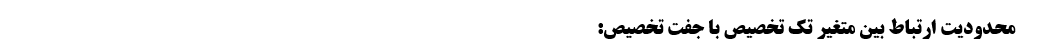

In [25]:
#for a in range(n-1):
#    #print()
#    for k in M[a]:
#        mdl_sum=0
#        for element in A:
#            if element[0]==a:
#                #print(a, element)
#                #for k in M[a]:
#                for h in M[element[1]]:
#                    print('XX[',str(a), ',' , str(element[1]), ',' , str(k+1), ',', str(h+1), ']' )
#                    mdl_sum += mdl.sum(XX[a,element[1],k,h]) #for k in M[a] for h in M[element[1]]
#                    #print(mdl_sum)
#        print('X[' ,str(a),',', str(k+1), ']')
#        mdl.add_constraint(mdl_sum >=X[a,k])     

In [26]:
mdl.print_information()

Model: Dynamic service selection and scheduling in cloud manufacturing = FJSP-DAG-Unavaiability-Transportation
 - number of variables: 205
   - binary=158, integer=0, continuous=47
 - number of constraints: 358
   - linear=358
 - parameters:
     parameters.threads = 1
     parameters.mip.tolerances.absmipgap = 0.00000000000000
     parameters.mip.tolerances.mipgap = 0.00000000000000
 - objective: minimize
 - problem type is: MILP


In [27]:
mdl.solve()
mdl.print_solution()
print()
for element in A:
    i = element[0]
    j = element[1]
    print('tp['+ str(i+1) + ''  + str(j+1) +  ']:' ,pp[i, j], pp[i,j].solution_value)
    for k in F[i]:
        for l in F[j]:
            print('XX:[' + str(i+1)+ ','  +str(j+1) + ','  + str(k+1) + ','  + str(l+1) + ']:', XX[i,j,k,l].solution_value)

objective: 43.000
status: OPTIMAL_SOLUTION(2)
  x1=1
  x3=1
  x7=1
  x8=1
  x12=1
  x22=1
  x25=1
  x29=1
  x33=1
  x39=1
  x45=1
  x48=9.000
  x49=16.000
  x50=10.000
  x51=3.000
  x52=4.000
  x53=5.000
  x54=4.000
  x55=6.000
  x57=1.000
  x59=2.000
  x62=2.000
  x63=1.000
  x66=1.000
  x68=4.000
  x69=12.000
  x70=7.000
  x71=20.000
  x72=23.000
  x73=23.000
  x74=27.000
  x75=32.000
  x76=37.000
  x77=43.000
  x78=4.000
  x79=21.000
  x80=23.000
  x81=30.000
  x82=26.000
  x83=27.000
  x84=32.000
  x85=36.000
  x86=43.000
  x87=43.000
  Y_0_2=1
  Y_0_5=1
  Y_0_6=1
  Y_0_7=1
  Y_1_4=1
  Y_1_8=1
  Y_1_9=1
  Y_2_5=1
  Y_2_6=1
  Y_2_7=1
  Y_3_8=1
  Y_4_8=1
  Y_4_9=1
  Y_5_6=1
  Y_5_7=1
  Y_6_7=1
  Y_8_9=1
  FM_0_0=7.000
  FM_1_0=12.000
  FM_1_1=36.000
  FM_2_0=4.000
  FM_2_1=14.000
  Z_0_0_0=1
  Z_1_1_1=1
  Z_3_1_1=1
  Z_4_1_1=1
  CMAX=43.000

tp[12]: x57 1.0
XX:[1,2,1,2]: 1.0
XX:[1,2,1,3]: 0
tp[13]: x58 0
XX:[1,3,1,1]: 1.0
XX:[1,3,1,3]: 0
tp[14]: x59 2.0
XX:[1,4,1,1]: 0
XX:[1,4,1,2]: 

In [28]:
#X       = {(i, k)    : mdl.binary_var() for i in range(N) for k in F[i]}                            # x(ik)
#print(Cmax.solution_value)
X=[]
for n in range(N):
    for el in A:
        i=el[0]
        j=el[1]
        if i==n:
            for k in F[i]:
                for l in F[j]:
                    if XX[i,j,k,l].solution_value == 1:
                        X.append(str(i)+ ','+ str(k)) 
                        
            break
print(X)

['0,0', '1,1', '2,0', '3,2', '4,1', '5,0', '6,0', '7,0', '8,1']


0 , 0 , 1 , 0 , 1
0 0
1 , 1 , 4 , 1 , 1
1 9
2 , 2 , 5 , 0 , 0
0 16
3 , 3 , 7 , 2 , 0
2 10
4 , 4 , 6 , 1 , 0
1 3
5 , 5 , 6 , 0 , 0
0 4
6 , 6 , 7 , 0 , 0
0 5
7 , 7 , 8 , 0 , 1
0 4
8 , 8 , 9 , 1 , 1
1 6


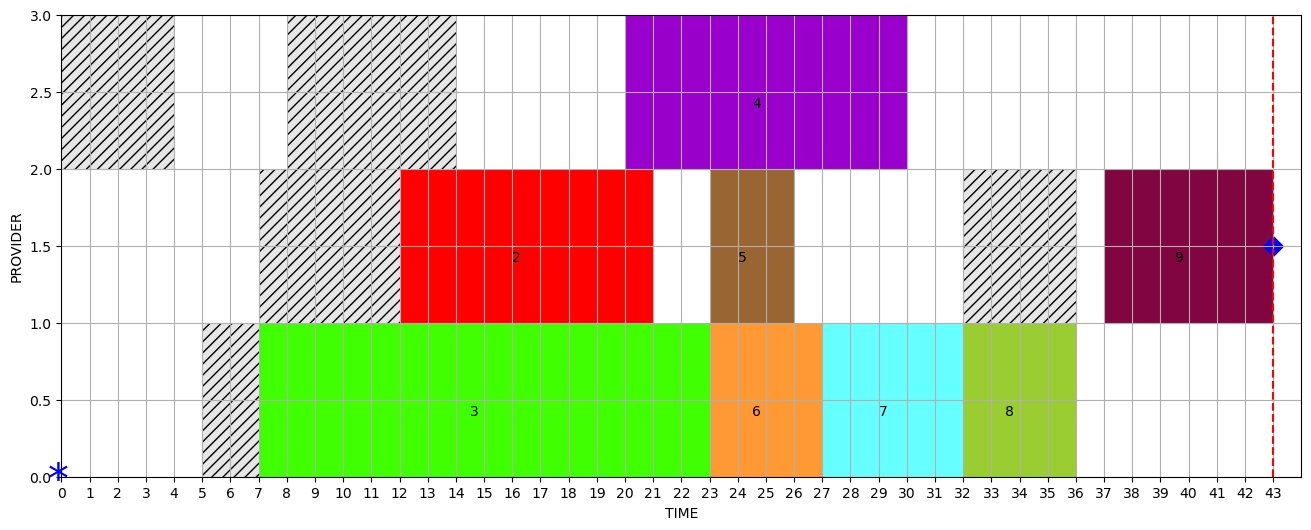

2


In [29]:
import matplotlib.pyplot as plt
#xaax=int(Cmax.solution_value 
fig, gnt = plt.subplots(1, figsize=(16,6))
gnt.set_ylim(0, S)
gnt.set_xlim(0,int(Cmax.solution_value) +2 )
gnt.set_xticks(range(0, int(Cmax.solution_value) +2 ,1))
gnt.set_xlabel('TIME')
gnt.set_ylabel('PROVIDER')
#gnt.set_yticks(df.INDEX)
#gnt.set_yticklabels(df.NAME)
gnt.grid(True)
colors = ['#FF0000', '#40FF00', '#9900CC', '#996633', '#FF9933', '#66FFFF', '#9ACD32', '#810541', '#E42217', '#EB5406',
          '#F0E68C', '#32CD32', '#66CDAA', '#C0C0C0', '#E9967A', '#FFC0CB', '#FFA500', '#FFD700', '#BDB76B', '#33cc33', 
          '#9370DB', '#00FA9A', '#D8BFD8', '#8FBC8B', '#40E0D0', '#797979', '#C0C6C7', '#98AFC7', '#0000FF', '#EB5406', 
          '#00FF00', '#FBD5AB', '#00A36C', '#728C00', '#00FFFF', '#F4A460', '#665D1E', '#FF5F1F', '#F8B88B', '#7FFFD4',
          '#FF00FF', '#FFA500', '#00FFFF', '#686A6C', '#0020C2', '#50C878', '#808000', '#E2F516', '#E6BF83', '#622F22', 
          '#0059FF', '#3A5F0B', '#FFF0DB', '#FDBD01', '#804A00', '#C36241', '#7D0552', '#B1907F', '#FDD7E4', '#E75480',
          '#D462FF', '#C8A2C8', '#FAF0DD', 'E42217',  '#08A04B', '#E3F9A6', '#FFFF00', '#FE632A', '#FF0000', '#8D918D', 
          '#151BBD', '#93FFE8', '#808000', '#CCFB5D', '#FFFFCC']
#for i in range(N):
#    print('s['+ str(i+1) + ']:' ,s[i],s[i].solution_value)
#    for g,k in enumerate(F[i]): # g:index , k:value
#        print('x['+ str(k+1) + ']:' ,X[i, k], X[i, k].solution_value)
#        #print('XX['+ str(k+1) + ']:' ,X[i, k], X[i, k].solution_value)
#        #for el in A:
#        #    if el[0]==i:
#        #        sumi=mdl.sum(XX[i,el[1],k,l] for l in F[el[1]])
#        #        break
#        if X[i, k].solution_value !=  0:  
#            ss_c= colors[i-1]
#            mm= s[i].solution_value
#            nn= (( t[i][g] )/2)-0.5 # s[i].solution_value +
#            c= k+0.4
#            gnt.broken_barh([(s[i].solution_value, t[i][g])], (k,1) , facecolors =ss_c) # s[i].solution_value + 
#        #print(ss_c)
#            if k==0 and i==0 : #or k==0 and i==9:
#                gnt.text(mm + nn,c,str('') )
#            else:
#                gnt.text(mm + nn,c,str(k+1)+str(i+1) )
#for i in range(m):
#    for jj in range(len(linear_unavs)):
#            if linear_unavs[jj][2] == i:
#                gnt.broken_barh([(linear_unavs[jj][0], linear_unavs[jj][1] - linear_unavs[jj][0])], (i, 1), facecolors ='#e6e6e6', hatch='///',label=j* (j+1)) #'#000000',text=index

for i in range(N):
    for el in A:
        n = el[0]
        m = el[1]
        if i == n:
            for k in F[i]:
                for l in F[m]:
                    if XX[i,m,k,l].solution_value == 1:
                        #X.append(str(i)+ ','+ str(k))
                        ss_c= colors[i-1]
                        mm = s[i].solution_value
                        print(i,',',n,',',m,',', k,',',l)
                        print(k, tt[i][k] )#[0]
                        nn = (( tt[i][k] )/2)-0.5 # s[i].solution_value + #nn= (( t[i][g] )/2)-0.5[0]
                        c= k + 0.4
                        gnt.broken_barh([(s[i].solution_value, tt[i][k])], (k,1) , facecolors = ss_c) #[0] s[i].solution_value + 
                        #print(ss_c)
                        if  i == 0 or i==39: #or k==0 and i==9:k == 0 and
                            #plt.scatter(mm , c, marker='D', label='Cross', color='blue', s=100) 
                            gnt.text(-0.5, c - 0.5, str('*'), color='blue', fontsize = 30)
                        else:
                            gnt.text(mm + nn, c, str(i+1)) #str(k+1)+
                        
            break
gnt.axvline( Cmax.solution_value , color='red', linestyle='--', label= 'مقصد' ) #f'Milestone: {milestone_date.strftime("%Y-%m-%d")}') # milestone_date
#gnt.text(Cmax.solution_value, df2['Location'].iloc[-1], str('*'), color='blue', fontsize=20  )
plt.scatter(Cmax.solution_value, LOC[-1:][0][0] - 0.5 ,  marker='D', label='Cross', color='blue', s=100)#df2['Location'].iloc[-1]
for i in range(S):
    for l in range(len(unavs[i])):# L
        mn= FM[i,l].solution_value
        gnt.broken_barh([(mn-PM[i][l] , PM[i][l])], (i, 1), facecolors ='#e6e6e6', hatch='///',label=j* (j+1)) #'#000000',text=index

#for element in A:
#    i = element[0]
#    j = element[1]
#    print('tp['+ str(i+1) + ''  + str(j+1) +  ']:' ,pp[i, j], pp[i,j].solution_value)
#    for k in F[i]:
#        for l in F[j]:
#            if XX[i,j,k,l].solution_value == 1:
#                gnt.broken_barh([(s[i].solution_value+p[i].solution_value , pp[i,j].solution_value)], (k,1) , facecolors ='#e6e6e6', hatch='///',label=j* (j+1)) #'#000000',text=index # s[i].solution_value + 
#                # gnt.broken_barh([(EM[j][0], PM[j][0]),(EM[j][1], PM[j][1])], (j, 1), facecolors ='#e6e6e6', hatch='///',label=j* (j+1)) 

#ff=0
#for i in M[n-1]:
#    if X[n-1,i].solution_value != 0 :
#        ff=i
#gnt.broken_barh([(s[n-1].solution_value+p[n-1].solution_value ,TRT[TRL[i][0]-1][2])], (i,1) , facecolors ='#e6e6e6', hatch='///',label=i* (i+1)) 
plt.show()
print(df2['Location'].iloc[-1])